# **What is Keyword Extraction?**
Keyword extraction is defined as the task of Natural language processing that automatically identifies a set of terms to describe the subject of the text. This is an important method in information retrieval (IR) systems: keywords simplify and speed up research. Keyword extraction can be used to reduce text dimensionality for further text analysis (subject modeling text classification).

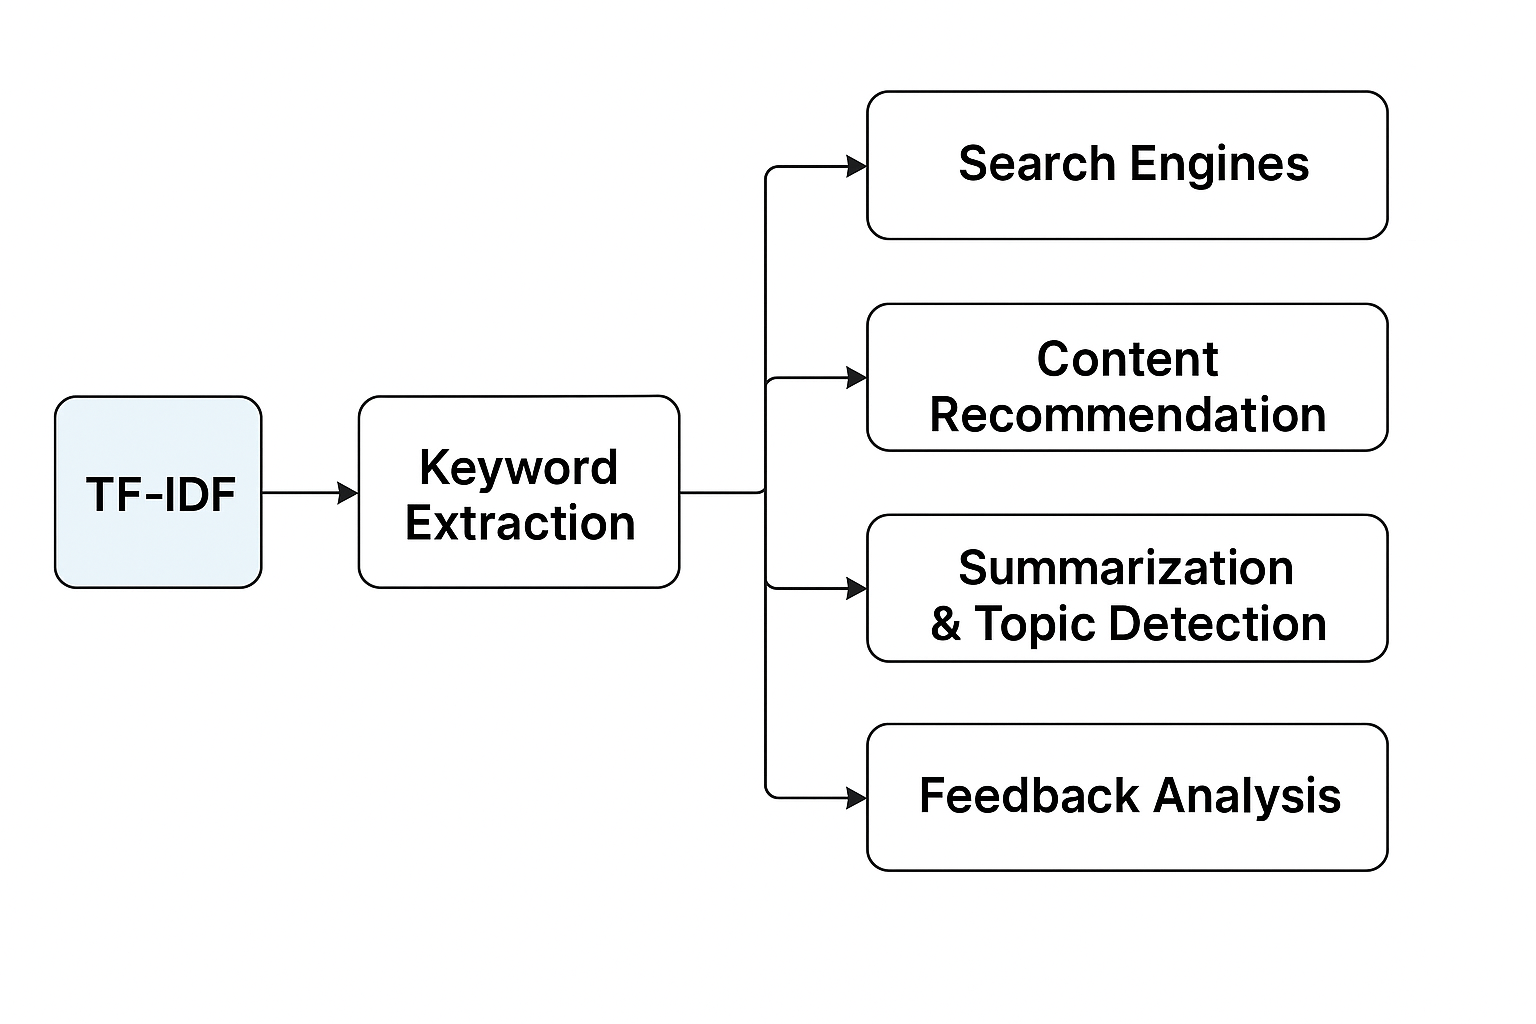

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [65]:
df = pd.read_csv("/content/papers.csv", engine='python', on_bad_lines='skip')
df

,id,year,title,event_type,pdf_name,abstract,paper_text
0,1,1987,Self-Organization of Associative Database and ...,NaN,1-self-organization-of-associative-database-an...,Abstract Missing,767\n\nSELF-ORGANIZATION OF ASSOCIATIVE DATABA...
1,10,1987,A Mean Field Theory of Layer IV of Visual Cort...,NaN,10-a-mean-field-theory-of-layer-iv-of-visual-c...,Abstract Missing,683\n\nA MEAN FIELD THEORY OF LAYER IV OF VISU...
2,100,1988,Storing Covariance by the Associative Long-Ter...,NaN,100-storing-covariance-by-the-associative-long...,Abstract Missing,394\n\nSTORING COVARIANCE BY THE ASSOCIATIVE\n...
3,1000,1994,Bayesian Query Construction for Neural Network...,NaN,1000-bayesian-query-construction-for-neural-ne...,Abstract Missing,Bayesian Query Construction for Neural\nNetwor...
4,1001,1994,"Neural Network Ensembles, Cross Validation, an...",NaN,1001-neural-network-ensembles-cross-validation...,Abstract Missing,"Neural Network Ensembles, Cross\nValidation, a..."
...,...,...,...,...,...,...,...
7236,994,1994,Single Transistor Learning Synapses,NaN,994-single-transistor-learning-synapses.pdf,Abstract Missing,Single Transistor Learning Synapses\n\nPaul Ha...
7237,996,1994,"Bias, Variance and the Combination of Least Sq...",NaN,996-bias-variance-and-the-combination-of-least...,Abstract Missing,"Bias, Variance and the Combination of\nLeast S..."
7238,997,1994,A Real Time Clustering CMOS Neural Engine,NaN,997-a-real-time-clustering-cmos-neural-engine.pdf,Abstract Missing,A Real Time Clustering CMOS\nNeural Engine\nT....
7239,998,1994,Learning direction in global motion: two class...,NaN,998-learning-direction-in-global-motion-two-cl...,Abstract Missing,Learning direction in global motion: two\nclas...


In [66]:
df.shape

(7241, 7)

#**NLTK to preprocess our textual data**

In [67]:
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [68]:
stop_words = stopwords.words('english')

In [69]:
len(stop_words)

198

In [70]:
##Creating a list of custom stopwords
new_words = ["fig","figure","image","sample","using",
             "show", "result", "large",
             "also", "one", "two", "three",
             "four", "five", "seven","eight","nine"]

In [71]:
stop_words.extend(new_words)

In [72]:
len(stop_words)

215

#**Text Preprocessing**

In [73]:
def pre_process(text):

  # Lower case
  text = text.lower()

  # remove tags
  text = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ",text)

  # remove special characters and digits
  text = re.sub("(\\d|\\W)+"," ",text)

  # Convert to list from string
  text = text.split()

  # remove stopwords
  text = [word for word in text if word not in stop_words]

  # remove words less than three letters
  text = [word for word in text if len(word) >= 3]

  # Lemmatize
  lmtzr = WordNetLemmatizer()
  text = [lmtzr.lemmatize(word) for word in text]

  return ' '.join(text)


In [74]:
docs = df['paper_text'].apply(lambda x:pre_process(x))
docs

,paper_text
0,self organization associative database applica...
1,mean field theory layer visual cortex applicat...
2,storing covariance associative long term poten...
3,bayesian query construction neural network mod...
4,neural network ensemble cross validation activ...
...,...
7236,single transistor learning synapsis paul hasle...
7237,bias variance combination least square estimat...
7238,real time clustering cmos neural engine serran...
7239,learning direction global motion class psychop...


**Using TF-IDF**

**CountVectorizer method in Scikit-learn to create a vocabulary and generate the word count**

In [75]:
from sklearn.feature_extraction.text import CountVectorizer

docs = docs.tolist()

#create a vocabulary of words
cv = CountVectorizer(max_df = 0.95,
                     max_features=10000,
                     ngram_range=(1,3)
                     )

In [76]:
word_count_vector = cv.fit_transform(docs)


In [77]:
word_count_vector.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [78]:
cnt_df = pd.DataFrame(word_count_vector.toarray(),columns = cv.get_feature_names_out())
cnt_df

,aaai,aaron,ab,abbeel,abbott,abc,ability,able,able learn,absence,...,zhao,zheng,zhou,zhu,zij,zinkevich,zisserman,zone,zoubin,zoubin ghahramani
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7236,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7237,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7238,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,4,0,0,0,0,0
7239,0,0,0,0,0,0,2,1,0,0,...,0,0,0,0,0,0,0,0,0,0


**TfidfTransformer in Scikit-learn to calculate the reverse frequency of documents**

In [79]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer(smooth_idf=True,use_idf=True)
# smooth_idf = adds a small value (1) to the document frequencies to prevent division by zero errors for terms that appear in all documents.
# use_idf = terms that are rare across the documents will have a higher weight than terms that are common.


tfidf_fit = tfidf.fit_transform(word_count_vector)
tfidf_fit.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [80]:
print(tfidf_fit.tocoo())

<COOrdinate sparse matrix of dtype 'float64'
	with 5934737 stored elements and shape (7241, 10000)>
  Coords	Values
  (0, 31)	0.01885532641109682
  (0, 36)	0.0367175669511393
  (0, 46)	0.08906099662943749
  (0, 59)	0.008098358060393114
  (0, 62)	0.008506477696562712
  (0, 123)	0.03122616638389594
  (0, 140)	0.019961459106506294
  (0, 158)	0.0347929099251629
  (0, 163)	0.014714362019587476
  (0, 175)	0.019770888893511907
  (0, 178)	0.013922575014323762
  (0, 235)	0.039372324073991445
  (0, 306)	0.01949753659806417
  (0, 342)	0.009940845410727858
  (0, 350)	0.017282542129678818
  (0, 354)	0.007797382147257195
  (0, 362)	0.011704778894449304
  (0, 380)	0.017956194756162076
  (0, 387)	0.005317265943239101
  (0, 413)	0.013403060309972173
  (0, 414)	0.019052791305811955
  (0, 436)	0.04028286245853585
  (0, 439)	0.02530638237540897
  (0, 455)	0.010510748526532433
  (0, 461)	0.015522260360273776
  :	:
  (7240, 9695)	0.036402001931195034
  (7240, 9696)	0.23335279579933704
  (7240, 9710)	0.03349

In [81]:
tfidf_df = pd.DataFrame(tfidf_fit.toarray(),columns = cv.get_feature_names_out())
tfidf_df

,aaai,aaron,ab,abbeel,abbott,abc,ability,able,able learn,absence,...,zhao,zheng,zhou,zhu,zij,zinkevich,zisserman,zone,zoubin,zoubin ghahramani
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.009444,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.004991,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7236,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.005901,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
7237,0.0,0.0,0.0,0.0,0.0,0.0,0.006697,0.005372,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
7238,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.008674,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.102964,0.0,0.0,0.0,0.0,0.0
7239,0.0,0.0,0.0,0.0,0.0,0.0,0.015302,0.006138,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


#**Creating a function for the task of Keyword Extraction with Python by using the Tf-IDF vectorization**

In [82]:
# Coo Matrix
#  sort_coo is about sorting values

def sort_coo(coo_matrix):
  # COO format stores a sparse matrix as three arrays: row, col, and data
  # row → row indices of non-zero elements
  # col → column indices of non-zero elements
  # data → actual non-zero values


  tuples = zip(coo_matrix.col,coo_matrix.data) # pairs of (column_index, value) for each non-zero element in the matrix.
  return sorted(tuples,key=lambda x: (x[1],x[0]),reverse=True),tuples

  #First sort by value (x[1], which is data).
  #If values are the same, sort by column index (x[0]).

In [83]:
sorted_items = sort_coo(tfidf_fit.tocoo())
sorted_items

([(np.int32(7866), np.float64(1.0)),
  (np.int32(2693), np.float64(0.946170659091305)),
  (np.int32(425), np.float64(0.9277440964638674)),
  (np.int32(5652), np.float64(0.9266356519595597)),
  (np.int32(425), np.float64(0.9222749496127711)),
  (np.int32(3813), np.float64(0.9206024577638983)),
  (np.int32(630), np.float64(0.9120051726905515)),
  (np.int32(6118), np.float64(0.9118051970003573)),
  (np.int32(2693), np.float64(0.9104378714892468)),
  (np.int32(2474), np.float64(0.9080105614787436)),
  (np.int32(3813), np.float64(0.9049629172942755)),
  (np.int32(5652), np.float64(0.9027847313371737)),
  (np.int32(9089), np.float64(0.9019976903355871)),
  (np.int32(1764), np.float64(0.9015563315025832)),
  (np.int32(3746), np.float64(0.9010203590279102)),
  (np.int32(5446), np.float64(0.9006702558844634)),
  (np.int32(2354), np.float64(0.8982551578003952)),
  (np.int32(1134), np.float64(0.8970287921335109)),
  (np.int32(6463), np.float64(0.8954157603231303)),
  (np.int32(1764), np.float64(0

In [84]:
# get feature names
feature_names = cv.get_feature_names_out()

In [85]:
#This function takes your sorted TF-IDF scores and converts them into a dictionary of the top N keywords and their importance scores.

def extract_topn_from_vector(feature_names,sorted_items,topn=10):
  """get the feature names and tf-idf score of top n items"""

  # use only topn item from vector
  sorted_items = sorted_items[:topn]
  results = {}
  for idx,score in sorted_items:
    results[feature_names[idx]] = round(score,3)
  return results


In [86]:

  keywords = extract_topn_from_vector(feature_names,sorted_items[0],10)
  keywords


{'score': np.float64(1.0),
 'epitome': np.float64(0.91),
 'annotator': np.float64(0.922),
 'motif': np.float64(0.927),
 'hint': np.float64(0.921),
 'attractor': np.float64(0.912),
 'ob': np.float64(0.912),
 'dropout': np.float64(0.908)}

In [87]:
def print_results(idx,keywords,df):
  # now print the results
    print("\n=====Title=====")
    print(df['title'][idx])
    print("\n=====Abstract=====")
    print(df['abstract'][idx])
    print("\n===Keywords===")

    for k in keywords:
      print(k,keywords[k])

idx=200
print_results(idx,keywords,df)




=====Title=====
Balancing Between Bagging and Bumping

=====Abstract=====
Abstract Missing

===Keywords===
score 1.0
epitome 0.91
annotator 0.922
motif 0.927
hint 0.921
attractor 0.912
ob 0.912
dropout 0.908
